In [45]:
import os
gpu_activate = True
if gpu_activate:
    os.environ["DEVITO_LANGUAGE"] = "openacc"
    os.environ["DEVITO_ARCH"]     = "nvc"
    os.environ["DEVITO_PLATFORM"] = "nvidiaX"  
from devito import configuration
configuration['log-level'] = 'ERROR'
print(configuration)
###############################
from devito import *
from examples.seismic import plot_velocity, RickerSource, TimeAxis, Receiver
from devitocurvilinear import SeismicModel
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sympy import init_printing, latex
import time
init_printing(use_latex='mathjax')

# Some ploting setup
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
fonttitle=18
fontlabel=12
savefig=True

Parameters([('platform', TargetPlatform[nvidiaX]), ('compiler', JITCompiler[NvidiaCompiler]), ('language', 'openacc'), ('mpi', False), ('topology', None), ('first-touch', False), ('ignore-unknowns', False), ('log-level', 'ERROR'), ('jit-backdoor', False), ('safe-math', False), ('autopadding', False), ('deviceid', -1), ('autotuning', (False, 'preemptive')), ('develop-mode', False), ('opt', 'advanced'), ('opt-options', {}), ('profiling', 'basic')])


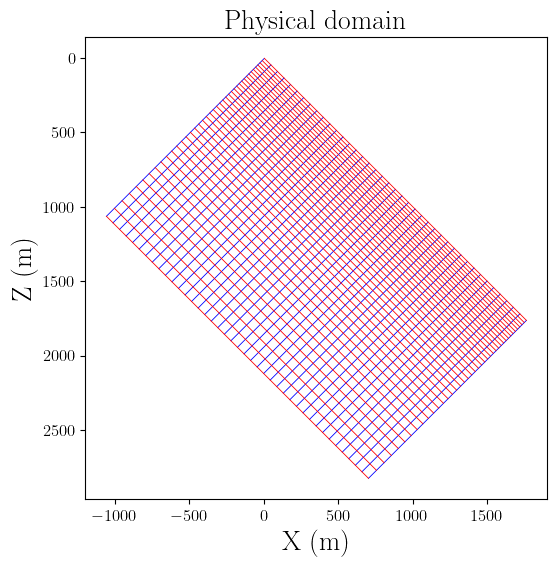

In [46]:

#######################################
from devitocurvilinear import meshgrid_from_topo

L = 2500.0       # period (m)
H = 1500.0        # depth extent for eta (m)
S = L/(2*np.pi)

def y_s(x):
    """Periodic topography y(x) over [0,L)."""
    x = np.asarray(x, dtype=float)
    base = 0*x
    #base = 250*np.sin(2*np.pi*x/L)+250
    return base
n_xi = 401
n_eta = 401
x_top = np.linspace(0.0, L, num=n_xi)
y_top = y_s(x_top)
X, Z = meshgrid_from_topo(x_top, y_top, n_xi=n_xi, n_eta=n_eta, H=H, max_iter=5,beta=2.0)
#X, Z = np.meshgrid(x_top, np.linspace(0.0, H, num=n_eta))
# Roration 45 degrees
theta = np.deg2rad(45)
X_rot =  X*np.cos(theta) - Z*np.sin(theta)
Z_rot =  X*np.sin(theta) + Z*np.cos(theta)
X = X_rot
Z = Z_rot
x_top_rot =  x_top*np.cos(theta) - y_top*np.sin(theta)
y_top_rot =  x_top*np.sin(theta) + y_top*np.cos(theta)
x_top = x_top_rot
y_top = y_top_rot
fig, ax = plt.subplots()
skip = 10
# --- Physical domain ---
for i in range(0, X.shape[1], skip):
    ax.plot(X[:, i], Z[:, i], linewidth=0.6, color='blue')
for j in range(0, X.shape[0], skip):
    ax.plot(X[j, :], Z[j, :], linewidth=0.6, color='red')
ax.set_xlabel('X (m)', fontsize=20)
ax.set_ylabel('Z (m)', fontsize=20)
ax.set_title('Physical domain', fontsize=20)
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

In [47]:
if 1:
    np.savetxt('top.dat', np.column_stack((x_top.flatten(), 2500-y_top.flatten())), fmt='%f')

In [48]:
from devitocurvilinear import CurviMap
eta = np.linspace(0.0, 1.0, num=n_eta)
xi = np.linspace(0.0, 1.0, num=n_xi)
Xi, Eta = np.meshgrid(xi, eta) 
cm = CurviMap(Xi, Eta, X, Z)
from scipy.interpolate import  interp1d
top = interp1d(X[0,:],Z[0,:], kind='linear', fill_value='extrapolate')
print(X[0,0],Z[0,0])
print(X[0,-1], Z[0,-1])


4.410398163268134 4.410398163268134
1764.1702638064135 1764.1702638064132


In [49]:
2500-2500*np.cos(theta)

np.float64(732.233047033631)

In [50]:
2500*np.cos(theta)

np.float64(1767.766952966369)

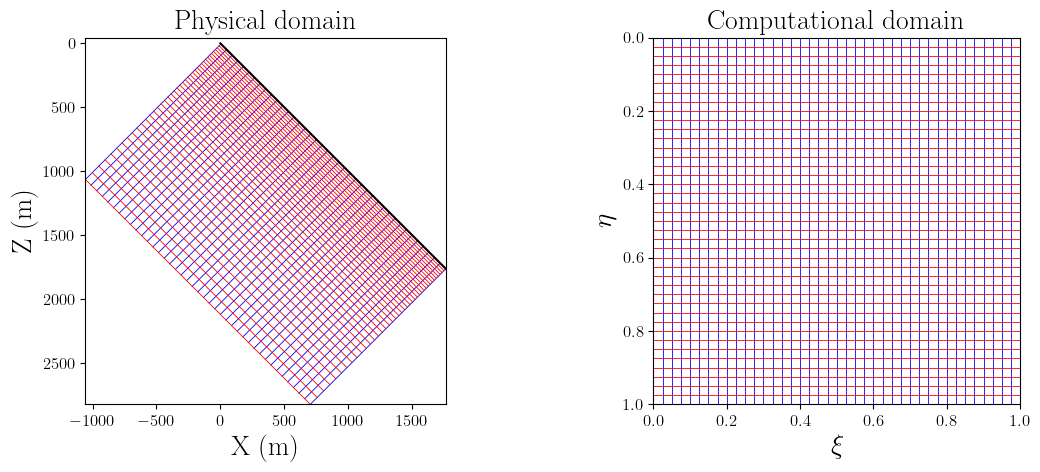

In [51]:

###################################
allplots = False
#if allplots:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
skip = 10
# --- Physical domain ---
for i in range(0, X.shape[1], skip):
    axes[0].plot(X[:, i], Z[:, i], linewidth=0.6, color='blue')
for j in range(0, X.shape[0], skip):
    axes[0].plot(X[j, :], Z[j, :], linewidth=0.6, color='red')
axes[0].set_xlabel('X (m)', fontsize=20)
axes[0].set_ylabel('Z (m)', fontsize=20)
axes[0].set_title('Physical domain', fontsize=20)
axes[0].set_xlim(X.min(), X.max())
axes[0].set_ylim(Z.max(), Z.min()-50)
axes[0].set_aspect('equal')
axes[0].plot(x_top, y_top, 'k', label='Smoothed')
# --- Computational domain ---
for i in range(0, Xi.shape[1], skip):
    axes[1].plot(Xi[:, i], Eta[:, i], linewidth=0.6, color='blue')
for j in range(0, Xi.shape[0], skip):
    axes[1].plot(Xi[j, :], Eta[j, :], linewidth=0.6, color='red')
axes[1].set_xlabel(r'$\xi$', fontsize=20)
axes[1].set_ylabel(r'$\eta$', fontsize=20)
axes[1].set_title('Computational domain', fontsize=20)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(1, 0)
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()
if savefig:
    fig.savefig('mesh_homotilted.pdf', transparent=True,bbox_inches='tight')

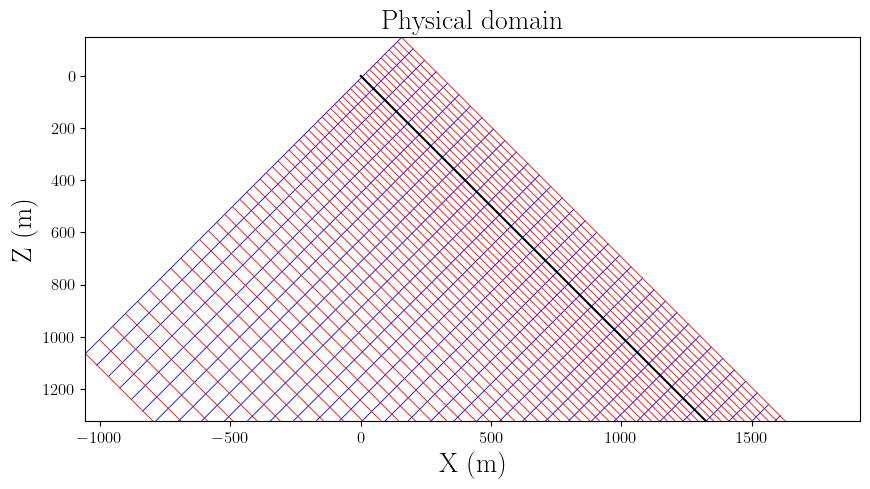

In [52]:
# Mirror 4 samples of X, and Z along axis eta (axis =0 )
Xmirror = np.vstack([2*X[0,:]-X[100:0:-1, :], X])
Zmirror = np.vstack([2*Z[0,:]-Z[100:0:-1, :], Z])

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
skip = 10
# --- Physical domain ---
for i in range(0, Xmirror.shape[1], skip):
    axes.plot(Xmirror[:, i], Zmirror[:, i], linewidth=0.6, color='blue')
for j in range(0, Xmirror.shape[0], skip):
    axes.plot(Xmirror[j, :], Zmirror[j, :], linewidth=0.6, color='red')
axes.set_xlabel('X (m)', fontsize=20)
axes.set_ylabel('Z (m)', fontsize=20)
axes.set_title('Physical domain', fontsize=20)
axes.set_xlim(Xmirror.min(), Xmirror.max())
axes.set_ylim(Zmirror.max()-1500, Zmirror.min())
axes.set_aspect('equal')
axes.plot(x_top, top(x_top), 'k', label='Smoothed')

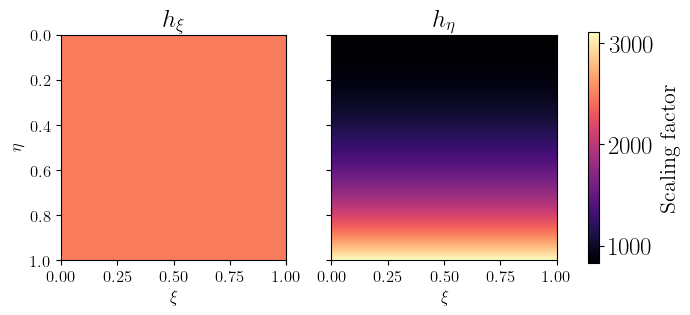

In [53]:
#######################################
from devitocurvilinear import deriv1_8th
deta = eta[1]-eta[0]
dxi  = xi[1]-xi[0]
# x_eta, x_xi = np.gradient(X, deta, dxi, edge_order=2)   # shape (ny, nx)
# z_eta, z_xi = np.gradient(Z, deta, dxi, edge_order=2)   # shape (ny, nx)
# X, Z have shape (ny, nx) with axes: eta (0), xi (1)
x_eta = deriv1_8th(X, deta, axis=0)
x_xi  = deriv1_8th(X, dxi,  axis=1)

z_eta = deriv1_8th(Z, deta, axis=0)
z_xi  = deriv1_8th(Z, dxi,  axis=1)

a_xi = (x_xi, z_xi)/np.sqrt(x_xi**2+z_xi**2)
a_eta = (x_eta, z_eta)/np.sqrt(x_eta**2+z_eta**2)
h_xi = np.sqrt(x_xi**2 + z_xi**2)
h_eta = np.sqrt(x_eta**2 + z_eta**2)

hmap = 'magma'
hmin, hmax = min(h_xi.min(), h_eta.min()), max(h_xi.max(), h_eta.max())
fig, ax = plt.subplots(1, 2,  sharey=True)
im0 = ax[0].imshow(h_xi, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=hmin, vmax=hmax)
ax[0].set_title(r'$h_\xi$', fontsize=fonttitle)
ax[0].set_ylabel(r'$\eta$', fontsize=fontlabel)
ax[0].set_xlabel(r'$\xi$', fontsize=fontlabel)
#cb=fig.colorbar(im0, ax=ax[0], label='(m)',orientation='horizontal')
#cb.ax.tick_params(labelsize=14)
im1 = ax[1].imshow(h_eta, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=hmin, vmax=hmax)
ax[1].set_title(r'$h_\eta$', fontsize=fonttitle)
ax[1].set_xlabel(r'$\xi$', fontsize=fontlabel)
cb=fig.colorbar(im1, ax=ax, label='Scaling factor',orientation='vertical',shrink=0.5)
cb.ax.tick_params(labelsize=18)
plt.show()

if savefig:
    fig.savefig('scaling_homotilted.pdf', transparent=True,bbox_inches='tight')


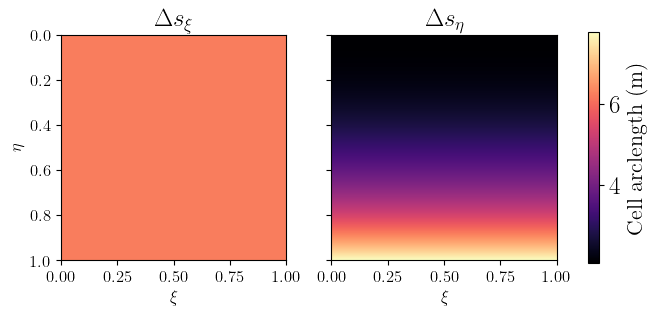

Minimum and maximum arclengths per axis:
Delta s_xi: min = 6.2216906712286635, max = 6.221690671290542
Delta s_eta: min = 2.067904235784264, max = 7.779860405470157


In [54]:
dsxi = h_xi*dxi
dseta = h_eta*deta
hmap = 'magma'
dmin, dmax = min(dsxi.min(), dseta.min()), max(dsxi.max(), dseta.max())
fig, ax = plt.subplots(1, 2,  sharey=True)
im0 = ax[0].imshow(dsxi, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=dmin, vmax=dmax)
ax[0].set_title(r'$\Delta s_\xi$', fontsize=fonttitle)
ax[0].set_ylabel(r'$\eta$', fontsize=fontlabel)
ax[0].set_xlabel(r'$\xi$', fontsize=fontlabel)
#cb=fig.colorbar(im0, ax=ax[0], label='(m)',orientation='horizontal')
#cb.ax.tick_params(labelsize=14)
im1 = ax[1].imshow(dseta, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=dmin, vmax=dmax)
ax[1].set_title(r'$\Delta s_\eta$', fontsize=fonttitle)
ax[1].set_xlabel(r'$\xi$', fontsize=fontlabel)
cb=fig.colorbar(im1, ax=ax, label='Cell arclength (m)',orientation='vertical',shrink=0.5)
cb.ax.tick_params(labelsize=18)
plt.show()
# print minimum and maximum arclengths per axis
print(f"Minimum and maximum arclengths per axis:")
print(f"Delta s_xi: min = {dsxi.min()}, max = {dsxi.max()}")
print(f"Delta s_eta: min = {dseta.min()}, max = {dseta.max()}")
if savefig:
    fig.savefig('length_homotilted.pdf', transparent=True,bbox_inches='tight')

Minimim Jacobian value: 2058537.6788572837
Maximum orthogonality value: 3.7155139598969814e-12


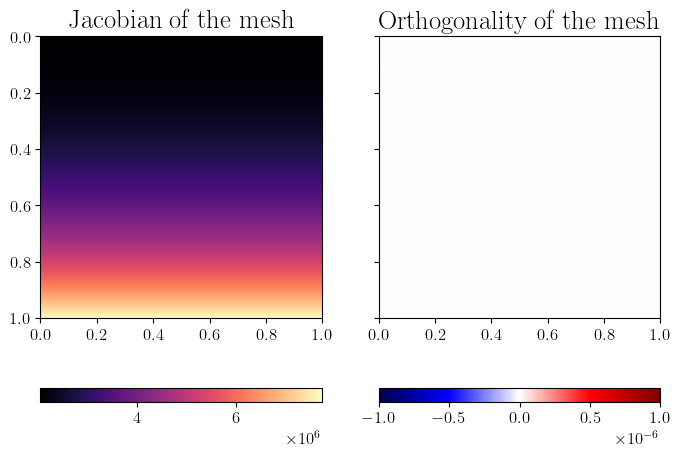

In [55]:
# Mesh orthogonality check
J = x_xi * z_eta - x_eta * z_xi
O = (x_xi * x_eta + z_xi * z_eta) / (np.sqrt(x_xi**2 + z_xi**2) * np.sqrt(x_eta**2 + z_eta**2))
#O = (x_xi * x_eta + z_xi * z_eta) 
print("Minimim Jacobian value:", np.min(J))
print("Maximum orthogonality value:", np.max(O))
fig, ax = plt.subplots(1, 2,  sharey=True)
im1 = ax[0].imshow(J, cmap='magma', extent=[xi.min(), xi.max(), eta.max(), eta.min()])
fig.colorbar(im1, ax=ax[0], orientation='horizontal')
ax[0].set_title("Jacobian of the mesh")
im2 = ax[1].imshow(O, cmap='seismic', extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=-1e-6, vmax=1e-6)
fig.colorbar(im2, ax=ax[1], orientation='horizontal')
ax[1].set_title("Orthogonality of the mesh")
plt.show()

Time step: 0.60 ms
335.00 2136.71
(array([0.19840377]), array([0.02416959]))


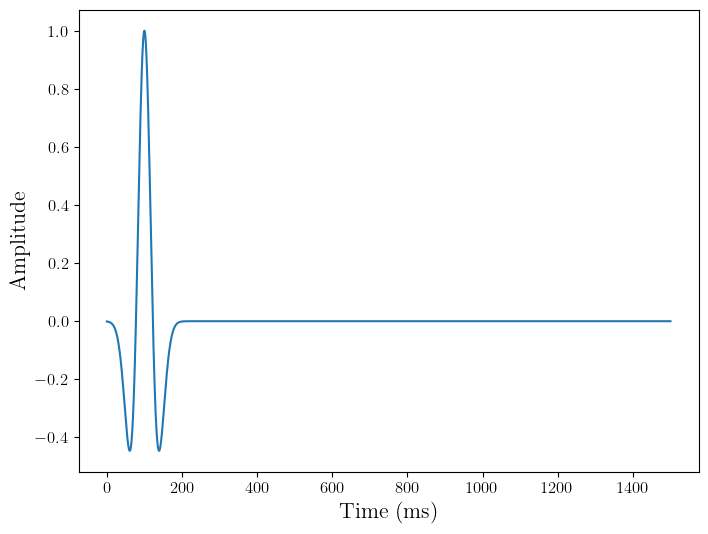

419.85 1763.36


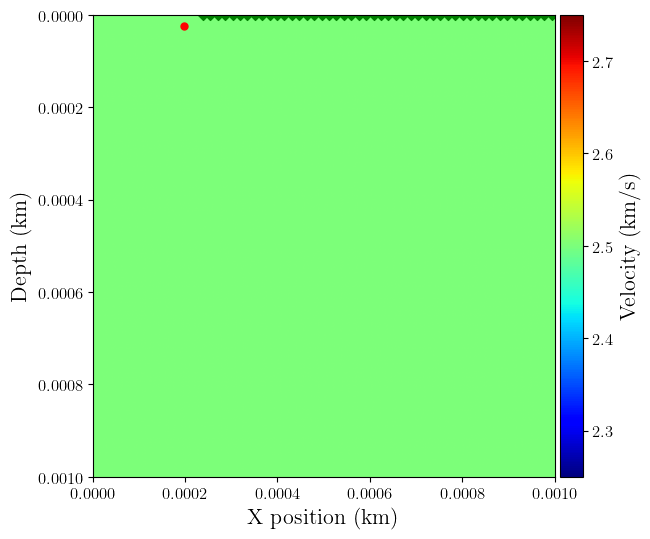

In [67]:
shape = Xi.T.shape # Number of grid point (nx, nz)
spacing = (dxi, deta)  # Grid spacing in m. 
origin = (0., 0.)  # What is the location of the top left corner. This is necessary to define
so= 4
nbl=50
vp = 2.5 * np.ones(shape, dtype=np.float32)  # Velocity in km/s
vs = 1.3 * np.ones(shape, dtype=np.float32)  # Shear velocity in km/s
b = 0.5 * np.ones(shape, dtype=np.float32)
# With the velocity and model size defined, we can create the seismic model that
# encapsulates this properties. We also define the size of the absorbing layer as 10 grid points
vmax = vp.max()
#W = np.array([9/8,-1/24])
W = np.array([1225/1024, -245/3072, 49/5120, -5/7168])
dt = 0.99/((np.sqrt((1/(dxi*h_xi.min()))**2 + (1/(deta*h_eta.min()))**2))*vmax*np.sum(np.abs(W))) 
print(f"Time step: {dt:.2f} ms")
model = SeismicModel(vp=vp, vs=vs, b=b, dt=dt, hxi=h_xi.T, heta=h_eta.T, 
                     origin=origin, shape=shape, spacing=spacing, space_order=so, nbl=nbl,fs=True, bcs='damp')

###########################################
t0 = 0.  # Simulation starts a t=0
tn = 1500.  # Simulation last 1 second (1000 ms)
time_range = TimeAxis(start=t0, stop=tn, step=dt)

f0 = 0.010  # Source peak frequency is 10Hz (0.010 kHz)
src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
shotposx= 500.  # Source position in m
shotposz= 20.# Depth is 10m
shotposx_rot = shotposx*np.cos(theta) - shotposz*np.sin(theta)
shotposz_rot = shotposx*np.sin(theta) + shotposz*np.cos(theta)
shotposx = shotposx_rot
shotposz = shotposz_rot
print(f"{shotposx-X[0,0]:.2f} {2500-shotposz+Z[0,0]:.2f}")
coordinates = cm.p2c(np.array([shotposx]), np.array([shotposz]))
print(coordinates)
src.coordinates.data[:] = np.vstack((coordinates[0], coordinates[1])).T
src.show()

############################################
s = model.grid.time_dim.spacing
v = VectorTimeFunction(name='v', grid=model.grid, space_order=so, time_order=1)
tau = TensorTimeFunction(name='tau', grid=model.grid, space_order=so, time_order=1)

src_xx = src.inject(field=tau.forward[0, 0], expr=s*src)
src_zz = src.inject(field=tau.forward[1, 1], expr=s*src)

# Receivers
#rec_coordsx = np.linspace(X[0, 0], X[0, -2], num=401)
rec_coordsx = np.linspace(600, 2500, num=191)
rec_coordsz = 0.0*np.ones(rec_coordsx.shape)# Depth is 10m
rec_coordsx_rot = rec_coordsx*np.cos(theta) - rec_coordsz*np.sin(theta)
rec_coordsz_rot = rec_coordsx*np.sin(theta) + rec_coordsz*np.cos(theta)
rec_coordsx = rec_coordsx_rot
rec_coordsz = rec_coordsz_rot
print(f"{rec_coordsx[0]-X[0,0]:.2f} {rec_coordsx[-1]-X[0,0]:.2f}")
#print(rec_coordsx)
rec_coords = np.vstack(cm.p2c(rec_coordsx, rec_coordsz)).T
recvx = Receiver(name="recvx", grid=model.grid, time_range=time_range, coordinates=rec_coords)
recvz = Receiver(name="recvz", grid=model.grid, time_range=time_range, coordinates=rec_coords) 
rec_term = recvx.interpolate(expr=v[0])
rec_term += recvz.interpolate(expr=v[1])

plot_velocity(model, source=src.coordinates.data, receiver=recvx.coordinates.data[::4, :])

In [68]:
############################################
x, y = model.grid.dimensions
k=1
class Main(SubDomain):
    name = 'main'
    def define(self, dimensions):
        x, y = dimensions
        return {
            x: x,                    # full width; or ('middle', nbl, nbl) to drop side PML
            y: ('middle', k, 0)      # exclude k rows at top, 0 at bottom
        }

class FreeSurface(SubDomain):
    name = 'freesurface'
    def define(self, dimensions):
        x, y = dimensions
        return {
            x: x,                    # full width; or ('middle', nbl, nbl)
            y: ('left', k)           # first k rows only (top band)
        }

main = Main(grid=model.grid)
freesurface = FreeSurface(grid=model.grid)

##############################################################################
# Lame parameters
l, mu, ro = model.lam, model.mu, model.b
# Scaling factors for curvilinear coordinates
hxi, heta = model.hxi, model.heta

model.damp.data[:] = np.exp(-(1e-3)*model.damp.data)
 
div_corr_x = (tau[0,1] * hxi.dy - tau[1,1] * heta.dx) / (hxi*heta)
div_corr_z = (tau[0,1] * heta.dx - tau[0,0] * hxi.dy) / (hxi*heta)

u_vx = Eq(v[0].forward,
          model.damp * solve(v[0].dt
                             - ro*(1/(hxi*heta))*((heta*tau[0,0]).dx + (hxi*tau[0,1]).dy)
                             - ro*div_corr_x,
                             v[0].forward),
          subdomain=model.grid)

u_vz = Eq(v[1].forward,
          model.damp * solve(v[1].dt
                             - ro*(1/(hxi*heta))*((heta*tau[0,1]).dx + (hxi*tau[1,1]).dy)
                             - ro*div_corr_z,
                             v[1].forward),
          subdomain=model.grid)

vz_c = v[1].forward 
vx_c = v[0].forward 
vx_s = v[0].forward 
vz_s = v[1].forward 


u_txx = Eq(tau[0,0].forward, model.damp * solve(
    tau[0,0].dt - (
        (l+2*mu)*((1/hxi)*v[0].forward.dx +
                  (1/(hxi*heta))* (vz_c) * hxi.dy) +
        l*((1/heta)*v[1].forward.dy +
           (1/(hxi*heta))* (vx_c) * heta.dx)
    ),
    tau[0,0].forward),
    subdomain=main)

u_tzz = Eq(tau[1,1].forward, model.damp * solve(
    tau[1,1].dt - (
        l*((1/hxi)*v[0].forward.dx +
           (1/(hxi*heta))* (vz_c) * hxi.dy) +
        (l+2*mu)*((1/heta)*v[1].forward.dy +
                  (1/(hxi*heta))* (vx_c) * heta.dx)
    ),
    tau[1,1].forward),
    subdomain=main)

u_txz = Eq(tau[0,1].forward, model.damp * solve(
    tau[0,1].dt - mu*(
        (1/heta)*v[0].forward.dy +
        (1/hxi)*v[1].forward.dx -
        (1/(hxi*heta))* (vx_s) * hxi.dy -
        (1/(hxi*heta))* (vz_s) * heta.dx
    ),
    tau[0,1].forward),
    subdomain=model.grid)


u_v = [u_vx, u_vz]
u_tau = [u_txx, u_txz, u_tzz]


# Free surface condition
bc_tzz = Eq(tau[1,1].forward, 0, subdomain=freesurface)
bc_txx = Eq(tau[0,0].forward, model.damp * solve(tau[0,0].dt - ((4*mu*(l+mu))/(l+2*mu))* ((1/hxi)*v[0].forward.dx + 
                                                              (1/(hxi*heta))*vz_c * hxi.dy), 
                                                 tau[0,0].forward), subdomain=freesurface)

# Stress image method
bc_tzz1 = Eq(tau[1,1].forward.subs({y: y-1}), -tau[1,1].forward.subs({y: y+1}), subdomain=freesurface)
bc_txz1 = Eq(tau[0,1].forward.subs({y: y-1}), -tau[0,1].forward, subdomain=freesurface)
bc_txz2 = Eq(tau[0,1].forward.subs({y: y-2}), -tau[0,1].forward.subs({y: y+1}), subdomain=freesurface)

eqns = u_v  + u_tau + [bc_txx] + [bc_tzz, bc_tzz1] + [bc_txz1, bc_txz2] + src_xx + src_zz + rec_term
if so==8 :
    bc_tzz2 = Eq(tau[1,1].forward.subs({y: y-2}), -tau[1,1].forward.subs({y: y+2}), subdomain=freesurface)
    bc_tzz3 = Eq(tau[1,1].forward.subs({y: y-3}), -tau[1,1].forward.subs({y: y+3}), subdomain=freesurface)
    bc_txz3 = Eq(tau[0,1].forward.subs({y: y-3}), -tau[0,1].forward.subs({y: y+2}), subdomain=freesurface)
    bc_txz4 = Eq(tau[0,1].forward.subs({y: y-4}), -tau[0,1].forward.subs({y: y+3}), subdomain=freesurface)
    eqns = u_v  + u_tau + [bc_txx] + [bc_tzz, bc_tzz1, bc_tzz2, bc_tzz3] + [bc_txz1, bc_txz2, bc_txz3, bc_txz4] + src_xx + src_zz + rec_term

op = Operator(eqns)

#############################
snap = int(0.4/(dt*1e-3))
start_time = time.perf_counter()
op(dt=dt, time_M=snap)
end_time = time.perf_counter()
elapsed_time1 = end_time - start_time

In [69]:
print(op.ccode)

#define _POSIX_C_SOURCE 200809L
#define START(S) struct timeval start_ ## S , end_ ## S ; gettimeofday(&start_ ## S , NULL);
#define STOP(S,T) gettimeofday(&end_ ## S, NULL); T->S += (double)(end_ ## S .tv_sec-start_ ## S.tv_sec)+(double)(end_ ## S .tv_usec-start_ ## S .tv_usec)/1000000;
#define SAFEINV(a, b) (((a) < 9.999999960041972e-13F || ((float)b) < 9.999999960041972e-13F) ? (0.0F) : ((1.0F) / (a)))

#include <cstdlib>
#include <cmath>
#include "sys/time.h"
#include "openacc.h"

struct dataobj
{
  void *__restrict data;
  int * size;
  unsigned long nbytes;
  unsigned long * npsize;
  unsigned long * dsize;
  int * hsize;
  int * hofs;
  int * oofs;
  void * dmap;
} ;

struct profiler
{
  double section0;
  double section1;
  double section2;
  double section3;
  double section4;
  double section5;
  double section6;
} ;

extern "C" int Kernel(struct dataobj *__restrict b_vec, struct dataobj *__restrict damp_vec, struct dataobj *__restrict heta_vec, struct dataobj *__restrict hxi

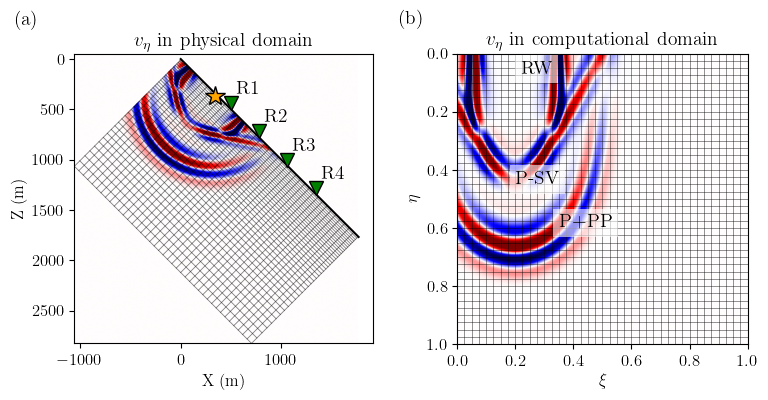

In [70]:
scale=1e-3
slices = [slice(model.nbl, -model.nbl), slice(0, -model.nbl)]
vz_comp = v[1].data[0][slices].T

xn,zn = np.linspace(X.min(), X.max(), 1000), np.linspace(Z.min()-50, Z.max(), 1000)
Xn,Zn = np.meshgrid(xn, zn)
from scipy.interpolate import griddata
v_phy = griddata(points=(X.ravel(), Z.ravel()),values=vz_comp.ravel(),xi=(Xn, Zn),method='linear',fill_value=0.0)
mask = Zn > top(Xn)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
skip = 10

# --- Left subplot: physical domain image (v_phy*mask) ---
ax = axes[0]
im1 = ax.imshow(
    v_phy * mask, cmap='seismic', vmin=-scale, vmax=scale,
    extent=[Xn.min(), Xn.max(), Zn.max(), Zn.min()]
)
ax.plot(x_top, top(x_top), color='black')
for i in range(0, X.shape[1], skip):
    ax.plot(X[:, i], Z[:, i], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
for j in range(0, X.shape[0], skip):
    ax.plot(X[j, :], Z[j, :], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
ax.set_aspect('equal', adjustable='box')
ax.set_title("$v_\\eta$ in physical domain", fontsize=14)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Z (m)', fontsize=12)
ax.plot(shotposx, shotposz, marker='*', linestyle='none', markersize=15, c='orange', markeredgewidth=1, markeredgecolor='k')
traces = [10,50,90,130]
ax.plot(rec_coordsx[traces], rec_coordsz[traces]-60, marker='v', linestyle='none', markersize=10, c='green', markeredgewidth=1, markeredgecolor='k')
ax.text(rec_coordsx[traces[0]]+50, rec_coordsz[traces[0]]-150, 'R1', fontsize=14)
ax.text(rec_coordsx[traces[1]]+50, rec_coordsz[traces[1]]-150, 'R2', fontsize=14)
ax.text(rec_coordsx[traces[2]]+50, rec_coordsz[traces[2]]-150, 'R3', fontsize=14)
ax.text(rec_coordsx[traces[3]]+50, rec_coordsz[traces[3]]-150, 'R4', fontsize=14)
#ax.text(0.0, 0.0, '(a)', fontsize=14)


# --- Right subplot: computational domain image (vz_comp) ---
ax = axes[1]
im0 = ax.imshow(
    vz_comp, cmap='seismic', vmin=-scale, vmax=scale,
    extent=[Xi.min(), Xi.max(), Eta.max(), Eta.min()]
)
for i in range(0, Xi.shape[1], skip):
    ax.plot(Xi[:, i], Eta[:, i], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
for j in range(0, Xi.shape[0], skip):
    ax.plot(Xi[j, :], Eta[j, :], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
ax.set_aspect('equal', adjustable='box')
ax.set_title("$v_\\eta$ in computational domain", fontsize=14)
ax.set_xlabel(r'$\xi$', fontsize=12)
ax.set_ylabel(r'$\eta$', fontsize=12)
ax.text(0.35, 0.6, 'P+PP', color='black', fontsize=14,  bbox=dict(
        facecolor='white',
        alpha=0.6,
        edgecolor='none'
    ))
ax.text(0.22, 0.07, 'RW', color='black', fontsize=14,  bbox=dict(
        facecolor='white',
        alpha=0.6,
        edgecolor='none'
    ))
ax.text(0.2, 0.45, 'P-SV', color='black', fontsize=14,  bbox=dict(
        facecolor='white',
        alpha=0.6,
        edgecolor='none'
    ))
axes[0].text(-0.2, 1.1, '(a)', fontsize=14, transform=axes[0].transAxes)
axes[1].text(-0.2, 1.1, '(b)', fontsize=14, transform=axes[1].transAxes)

plt.tight_layout()
plt.show()
if savefig:
    fig.savefig('wave_homotilted.pdf', transparent=True,bbox_inches='tight')


In [71]:
traces = [8,48,88,128]
(rec_coordsx[traces]-shotposx)/np.sin(theta)

array([ 200.,  600., 1000., 1400.])

In [72]:
500-rec_coordsx[traces]

array([  19.16738879, -263.67532368, -546.51803616, -829.36074863])

In [73]:
#############################
start_time = time.perf_counter()
op(dt=dt, time_m=snap)
end_time = time.perf_counter()
elapsed_time = end_time - start_time + elapsed_time1
print("Execution time:", elapsed_time )

Execution time: 0.8190959978383034


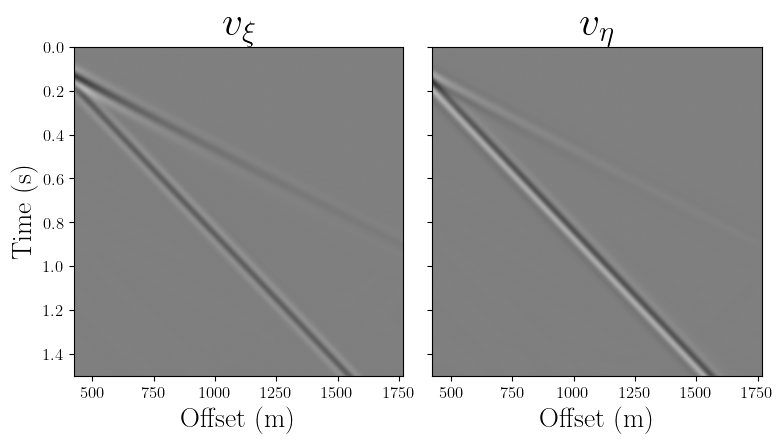

In [74]:
scale = 1e-2
#extent = [rec_coordsx[0]-shotposx, rec_coordsx[-1]-shotposx, 1e-3*tn, t0]
extent = [rec_coordsx[0], rec_coordsx[-1], 1e-3*tn, t0]
aspect = (rec_coordsx.max()-rec_coordsx.min())/(1e-3*tn)
v_xi = recvx.data
v_eta = recvz.data
fig, axes = plt.subplots(1, 2, sharey=True)
# Left: v_xi
im0 = axes[0].imshow(v_xi, vmin=-scale, vmax=scale, cmap="gray",
                     interpolation='lanczos', extent=extent, aspect=aspect)
axes[0].set_ylabel("Time (s)", fontsize=20)
axes[0].set_xlabel("Offset (m)", fontsize=20)
axes[0].set_title(r"$v_\xi$", fontsize=30)
# Right: v_eta
im1 = axes[1].imshow(v_eta, vmin=-scale, vmax=scale, cmap="gray",
                     interpolation='lanczos', extent=extent, aspect=aspect)
axes[1].set_xlabel("Offset (m)", fontsize=20)
axes[1].set_title(r"$v_\eta$", fontsize=30)

plt.tight_layout()
plt.show()

if savefig:
    fig.savefig('data_curvilinear_homotilted.pdf', transparent=True,bbox_inches='tight')


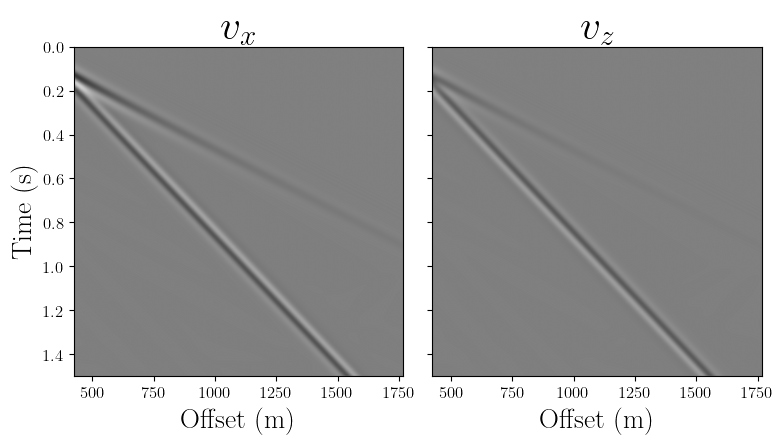

In [75]:
##########################################
vx, vz = cm.vel_c2p(v_xi, v_eta, rec_coordsx, rec_coordsz)
fig, axes = plt.subplots(1, 2, sharey=True)
# Left: v_x
axes[0].imshow(vx, vmin=-scale, vmax=scale, cmap="gray",
               interpolation='lanczos', extent=extent, aspect=aspect)
axes[0].set_ylabel("Time (s)", fontsize=20)
axes[0].set_xlabel("Offset (m)", fontsize=20)
axes[0].set_title(r"$v_x$", fontsize=30)
# Right: v_z
axes[1].imshow(vz, vmin=-scale, vmax=scale, cmap="gray",
               interpolation='lanczos', extent=extent, aspect=aspect)
axes[1].set_xlabel("Offset (m)", fontsize=20)
axes[1].set_title(r"$v_z$", fontsize=30)
plt.tight_layout()
plt.show()

if savefig:
    fig.savefig('data_cartesian_homo.pdf', transparent=True,bbox_inches='tight')

In [76]:
# save data to file
np.savez('data_devito_homotilted.npz', vx=vx, vz=vz, v_xi=v_xi, v_eta=v_eta, dt=dt, posx=rec_coordsx)